## 1. Import des bibliothèques

In [ ]:
from pathlib import Path
import random
import hashlib

from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import sys
import torch
from torchvision import models
from torchvision.io import read_image, ImageReadMode
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.model_selection import train_test_split

In [74]:
dossier_dataset = Path("mri_dataset_brain_cancer_oc")

print("Le dossier existe :", dossier_dataset.is_dir())

Le dossier existe : True


## Etape 1: Import des données et exploration des radios

Le dataset est organisé en deux répertoires: Un avec label et un sans label

`cancer`: Radio labelisée comme présentant une tumeur cancereuse
`normal` : Radio labelisée comme présentant une tumeur cancereuse

Le fichier .txt décerit le contenu du dataset: **1 500 images**, au format **JPEG**, dont 100 étiquetées et 1 400 sans label.

In [75]:
chemins_images = sorted(dossier_dataset.rglob("*.jpg"))

print("Nombre total d'images :", len(chemins_images))
print("Nombre annoncé dans le descriptif :", 1500)
print("Écart au descriptif :", len(chemins_images) - 1500)

Nombre total d'images : 1506
Nombre annoncé dans le descriptif : 1500
Écart au descriptif : 6


Comptons maintenant les images de chaque dossier.


In [76]:
dossiers = ["avec_labels/cancer", "avec_labels/normal", "sans_label"]
effectifs = []

for dossier in dossiers:
    fichiers = list((dossier_dataset / dossier).glob("*.jpg"))
    effectifs.append({
        "Dossier": dossier,
        "Nombre d'images": len(fichiers),
    })

tableau_effectifs = pd.DataFrame(effectifs)
display(tableau_effectifs)

,Dossier,Nombre d'images
0,avec_labels/cancer,50
1,avec_labels/normal,50
2,sans_label,1406


Ouverture d'une image et lecture de ses propriétés

In [77]:
chemin_exemple = chemins_images[0]

with Image.open(chemin_exemple) as image:
    print("Fichier :", chemin_exemple.name)
    print("Dossier :", chemin_exemple.parent.relative_to(dossier_dataset))
    print("Format :", image.format)
    print("Largeur :", image.width, "pixels")
    print("Hauteur :", image.height, "pixels")
    print("Mode de couleur :", image.mode)
    print("Canaux :", image.getbands())
    pixels = np.array(image)

print("Forme du tableau NumPy :", pixels.shape)

Fichier : 05340cd4-3bb2-459d-9937-bf27d52d8351.jpg
Dossier : avec_labels\cancer
Format : JPEG
Largeur : 512 pixels
Hauteur : 512 pixels
Mode de couleur : RGB
Canaux : ('R', 'G', 'B')
Forme du tableau NumPy : (512, 512, 3)


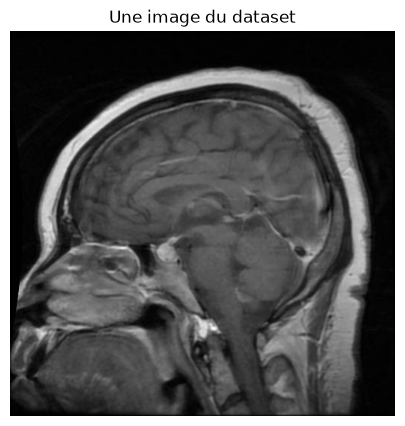

In [78]:
plt.figure(figsize=(5, 5))
plt.imshow(pixels)
plt.title("Une image du dataset")
plt.axis("off")
plt.show()

Affichage de quelques exemples de chaque dossier

random.seed(42) permet de retrouver la même sélection si rééxécution

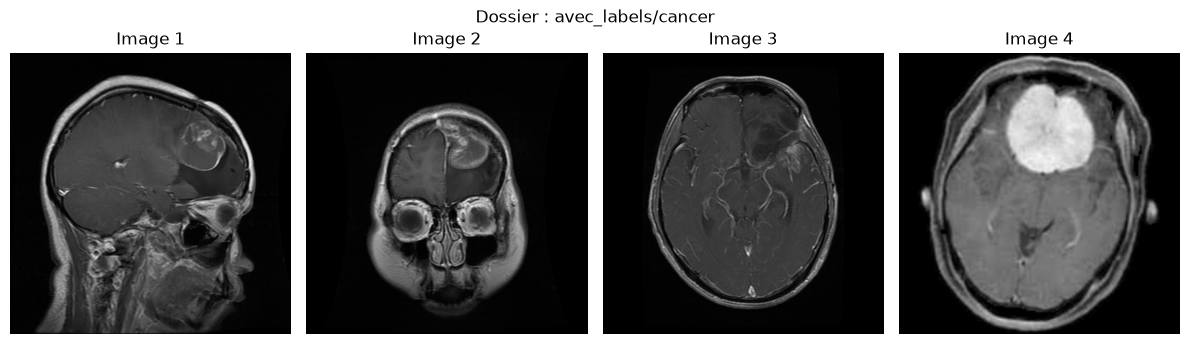

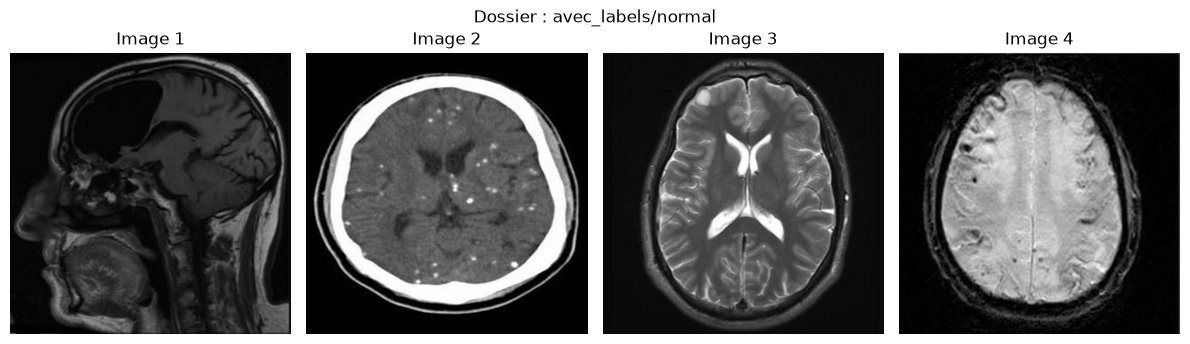

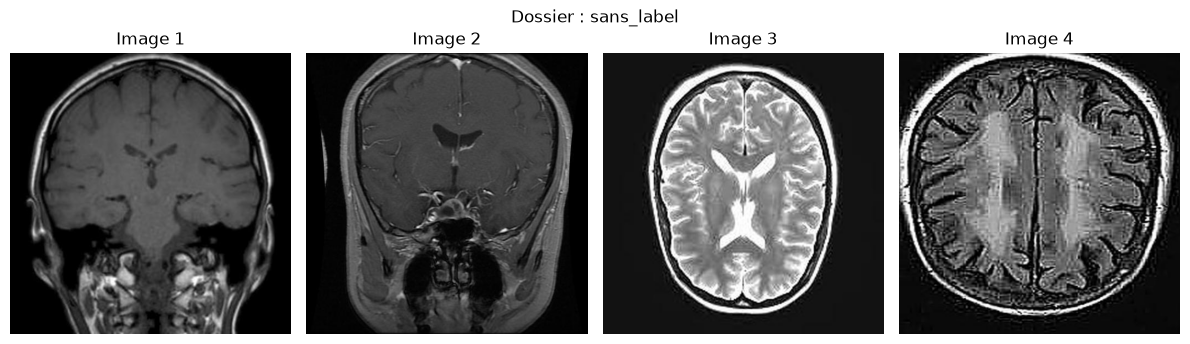

In [79]:
random.seed(42)

for dossier in dossiers:
    fichiers = sorted((dossier_dataset / dossier).glob("*.jpg"))
    exemples = random.sample(fichiers, min(4, len(fichiers)))

    plt.figure(figsize=(12, 3.5))
    for numero, chemin in enumerate(exemples, start=1):
        with Image.open(chemin) as image:
            pixels_exemple = np.array(image)

        plt.subplot(1, 4, numero)
        plt.imshow(pixels_exemple)
        plt.title(f"Image {numero}")
        plt.axis("off")

    plt.suptitle(f"Dossier : {dossier}")
    plt.tight_layout()
    plt.show()

échantillon de 100 images
Vérifications des dimensions, du mode de couleur, du nombre de canaux,
le format et la lisibilité 

In [80]:
random.seed(42)
echantillon = random.sample(chemins_images, min(100, len(chemins_images)))

print("Nombre d'images à vérifier :", len(echantillon))

Nombre d'images à vérifier : 100


Pour chaque fichier, appel de `image.load()` pour lire
ses pixels. Ses caractéristiques sont ajoutées à une liste.

In [81]:
caracteristiques = []
erreurs = []

for chemin in echantillon:
    try:
        with Image.open(chemin) as image:
            image.load()
            caracteristiques.append({
                "Fichier": chemin.name,
                "Dossier": str(chemin.parent.relative_to(dossier_dataset)),
                "Largeur": image.width,
                "Hauteur": image.height,
                "Mode": image.mode,
                "Canaux": len(image.getbands()),
                "Format": image.format,
            })
    except OSError as erreur:
        erreurs.append({"Fichier": str(chemin), "Erreur": str(erreur)})

controle = pd.DataFrame(caracteristiques)
display(controle.head())

,Fichier,Dossier,Largeur,Hauteur,Mode,Canaux,Format
0,de4a58ef-0572-499a-8b39-437d6605102e.jpg,sans_label,512,512,RGB,3,JPEG
1,1567a15d-5f22-46ca-a77c-cd88ee60b7fd.jpg,sans_label,512,512,RGB,3,JPEG
2,09316c60-86c8-4f24-934e-8d433b8b9d72.jpg,avec_labels\normal,512,512,RGB,3,JPEG
3,5674a7bf-6fe6-4c43-b574-fdd81608e18b.jpg,sans_label,512,512,RGB,3,JPEG
4,4a4822ad-22e0-4dac-a072-18fe2824cc9f.jpg,sans_label,512,512,RGB,3,JPEG


Regroupons les images pour vérifier qu'elles ont les mêmes caractéristiques

In [82]:
resume = controle.groupby(["Largeur", "Hauteur", "Mode", "Canaux"]).size()
display(resume.to_frame("Nombre d'images"))
display(controle["Format"].value_counts().to_frame("Nombre d'images"))

print("Images lisibles dans l'échantillon :", len(controle))
print("Erreurs de lecture :", len(erreurs))

if erreurs:
    display(pd.DataFrame(erreurs))

,,,,Nombre d'images
Largeur,Hauteur,Mode,Canaux,
512,512,RGB,3,100


,Nombre d'images
Format,
JPEG,100


Images lisibles dans l'échantillon : 100
Erreurs de lecture : 0


Recherche de doublons

In [83]:


images_vues = {}
doublons = []

for chemin in chemins_images:
    with Image.open(chemin) as image:
        image_rgb = image.convert("RGB")
        empreinte = hashlib.sha256(image_rgb.tobytes()).hexdigest()
        signature = (image_rgb.size, empreinte)

    if signature in images_vues:
        doublons.append((images_vues[signature], chemin))
    else:
        images_vues[signature] = chemin

print("Nombre d'images examinées :", len(chemins_images))
print("Nombre de copies supplémentaires :", len(doublons))

display(pd.DataFrame(doublons, columns=["Première image", "Copie"]))

Nombre d'images examinées : 1506
Nombre de copies supplémentaires : 96


,Première image,Copie
0,mri_dataset_brain_cancer_oc\avec_labels\normal...,mri_dataset_brain_cancer_oc\avec_labels\normal...
1,mri_dataset_brain_cancer_oc\avec_labels\normal...,mri_dataset_brain_cancer_oc\sans_label\04dd2b7...
2,mri_dataset_brain_cancer_oc\avec_labels\normal...,mri_dataset_brain_cancer_oc\sans_label\16a1699...
3,mri_dataset_brain_cancer_oc\avec_labels\normal...,mri_dataset_brain_cancer_oc\sans_label\18599c4...
4,mri_dataset_brain_cancer_oc\avec_labels\normal...,mri_dataset_brain_cancer_oc\sans_label\194106c...
...,...,...
91,mri_dataset_brain_cancer_oc\sans_label\1212636...,mri_dataset_brain_cancer_oc\sans_label\f84cb0d...
92,mri_dataset_brain_cancer_oc\avec_labels\cancer...,mri_dataset_brain_cancer_oc\sans_label\f946618...
93,mri_dataset_brain_cancer_oc\sans_label\abac225...,mri_dataset_brain_cancer_oc\sans_label\fa8ec37...
94,mri_dataset_brain_cancer_oc\sans_label\f9d60d2...,mri_dataset_brain_cancer_oc\sans_label\fcf1c2e...


regroupons e simages par dossier

In [84]:
fichiers_concernes = set()

for premiere_image, copie in doublons:
    fichiers_concernes.add(premiere_image)
    fichiers_concernes.add(copie)

dossiers_doublons = pd.Series(
    [chemin.parent.name for chemin in fichiers_concernes],
    name="Dossier"
)

classement = dossiers_doublons.value_counts()
classement = classement.reindex(
    ["sans_label", "cancer", "normal"], fill_value=0
)

display(classement.to_frame("Fichiers concernés"))

,Fichiers concernés
Dossier,
sans_label,154
cancer,8
normal,24


On effectue la recherche de doublons par dossier cette fois ci

In [85]:


for dossier in ["sans_label", "avec_labels/cancer", "avec_labels/normal"]:
    images_vues = {}
    doublons_dossier = []

    chemins = sorted((dossier_dataset / dossier).glob("*.jpg"))

    for chemin in chemins:
        with Image.open(chemin) as image:
            image_rgb = image.convert("RGB")
            empreinte = hashlib.sha256(image_rgb.tobytes()).hexdigest()
            signature = (image_rgb.size, empreinte)

        if signature in images_vues:
            doublons_dossier.append((images_vues[signature], chemin))
        else:
            images_vues[signature] = chemin

    print(f"{dossier} : {len(doublons_dossier)} copie(s) supplémentaire(s)")

    if doublons_dossier:
        display(pd.DataFrame(
            doublons_dossier,
            columns=["Première image", "Copie"]
        ))

sans_label : 64 copie(s) supplémentaire(s)


,Première image,Copie
0,mri_dataset_brain_cancer_oc\sans_label\11c7876...,mri_dataset_brain_cancer_oc\sans_label\21797d4...
1,mri_dataset_brain_cancer_oc\sans_label\01d4471...,mri_dataset_brain_cancer_oc\sans_label\3a1ca11...
2,mri_dataset_brain_cancer_oc\sans_label\3058ed0...,mri_dataset_brain_cancer_oc\sans_label\3a57247...
3,mri_dataset_brain_cancer_oc\sans_label\1d9eb25...,mri_dataset_brain_cancer_oc\sans_label\4ab4a1f...
4,mri_dataset_brain_cancer_oc\sans_label\070e468...,mri_dataset_brain_cancer_oc\sans_label\55e150d...
...,...,...
59,mri_dataset_brain_cancer_oc\sans_label\9f94cc0...,mri_dataset_brain_cancer_oc\sans_label\f5b5021...
60,mri_dataset_brain_cancer_oc\sans_label\1212636...,mri_dataset_brain_cancer_oc\sans_label\f84cb0d...
61,mri_dataset_brain_cancer_oc\sans_label\abac225...,mri_dataset_brain_cancer_oc\sans_label\fa8ec37...
62,mri_dataset_brain_cancer_oc\sans_label\f9d60d2...,mri_dataset_brain_cancer_oc\sans_label\fcf1c2e...


avec_labels/cancer : 0 copie(s) supplémentaire(s)
avec_labels/normal : 1 copie(s) supplémentaire(s)


,Première image,Copie
0,mri_dataset_brain_cancer_oc\avec_labels\normal...,mri_dataset_brain_cancer_oc\avec_labels\normal...


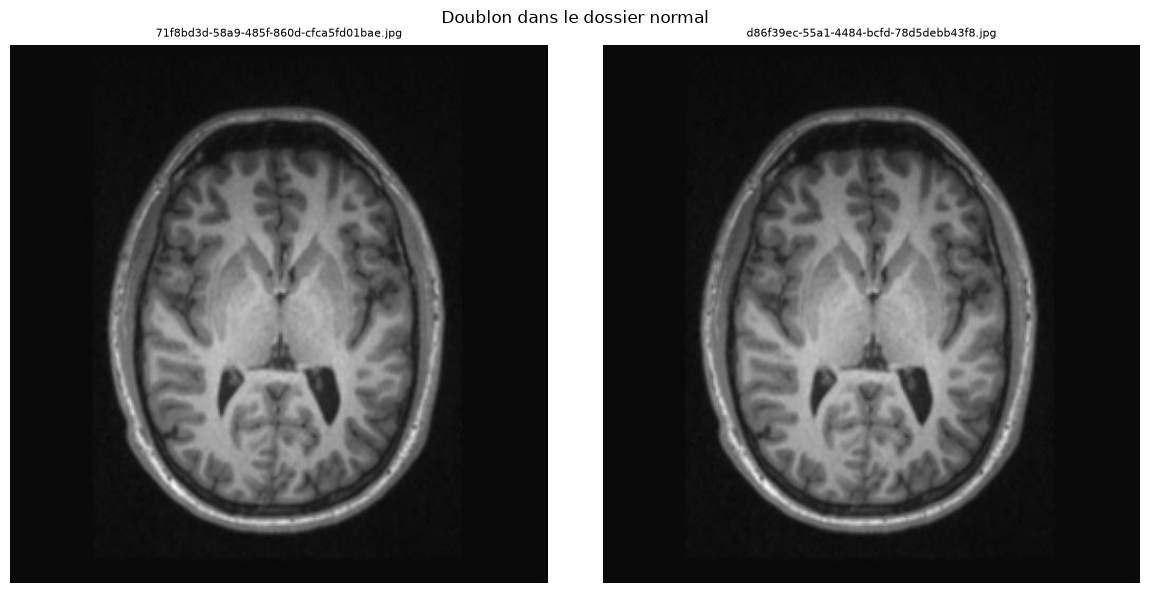

In [86]:
dossier_normal = Path("mri_dataset_brain_cancer_oc/avec_labels/normal")

fichiers = [
    "71f8bd3d-58a9-485f-860d-cfca5fd01bae.jpg",
    "d86f39ec-55a1-4484-bcfd-78d5debb43f8.jpg",
]

plt.figure(figsize=(12, 6))

for numero, nom in enumerate(fichiers, start=1):
    with Image.open(dossier_normal / nom) as image:
        plt.subplot(1, 2, numero)
        plt.imshow(image)

    plt.title(nom, fontsize=8)
    plt.axis("off")

plt.suptitle("Doublon dans le dossier normal")
plt.tight_layout()
plt.show()

Conclusion

- Le comptage donne **1 506 images JPEG** : 50 dans cancer, 50 dans normal
  et 1 406 dans sans_label.
- Les deux classes étiquetées sont équilibrées. 
- Le dossier sans label contient **six images de plus** qque l'enoncé
- Les **100 images contrôlées** mesurent **512 × 512 pixels** et sont stockées
  en **RGB, avec trois canaux**.
- Aucune erreur de lecture n'a été rencontrée dans cet échantillon.
- Les images montrent différentes orientations de coupe et différents cadrages.
- La place occupée par le cerveau, le contraste et la netteté apparente varient.
- Les exemples apparaissent principalement en niveaux de gris malgré le stockage RGB.
- Une même taille de 512 × 512 pixels ne garantit pas une qualité visuelle uniforme.
- Le data set contient des doublons:
  - 96 au total sur le set global
  - 1 dans le dossier lablélisé: Normal
  
  --> Ces doublons seront à traiter

Traitement des doublons

In [87]:
nombre_images_avant = len(chemins_images)

# Récupérer les chemins des copies supplémentaires.
copies_a_ecarter = {
    copie for premiere_image, copie in doublons
}

# Conserver uniquement la première occurrence de chaque image.
chemins_images = [
    chemin for chemin in chemins_images
    if chemin not in copies_a_ecarter
]

print("Images avant filtrage :", nombre_images_avant)
print("Copies écartées :", nombre_images_avant - len(chemins_images))
print("Images conservées pour l'étape 2 :", len(chemins_images))

Images avant filtrage : 1506
Copies écartées : 96
Images conservées pour l'étape 2 : 1410


## Etape 2: Prétraitement et extraction des features


Choix d'une version préentrainé de ResNet18: IMAGENET1K_V1
définition de la focntion prétraitement qui réalisera le redimensionnement des images, le recadrage, la conversion et la normalisation


In [88]:


poids = models.ResNet18_Weights.IMAGENET1K_V1
pretraitement = poids.transforms()
print(pretraitement)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Application de "pretraitement" à chaque image du dataset
Stockage du resultat dans la liste images_preparees


In [89]:
images_preparees = []

for chemin in chemins_images:
    image = read_image(str(chemin), mode=ImageReadMode.RGB)
    images_preparees.append(pretraitement(image))

print("Nombre d'images préparées :", len(images_preparees))
print("Forme d'une image préparée :", tuple(images_preparees[0].shape))
print("Type des valeurs :", images_preparees[0].dtype)

Nombre d'images préparées : 1410
Forme d'une image préparée : (3, 224, 224)
Type des valeurs : torch.float32


Chargement de ResNet avec le poids préentrainé précédement choisi
Gel des couches convutionelles avec `requires_grad = False` (cela gele tous les paramètres du modele, y compris les couches convutionelles donc cela repond à notre bespoin)

On prépare le modèle pour renvoyer les 512 nombres décrivant l’image avec identity(), puis modele.eval() pour utiliser le modele déjà entrainé

pui son verifie que les couches sont bien gelées en verifiant les paramètre entrainabels

In [90]:
modele = models.resnet18(weights=poids)

for parametre in modele.parameters():
    parametre.requires_grad = False

modele.fc = torch.nn.Identity()
modele.eval()

print("Nombre de paramètres entraînables :", sum(
    parametre.numel() for parametre in modele.parameters() if parametre.requires_grad
))

Nombre de paramètres entraînables : 0


Extractions des embeddings des images préparés:
- On traite les images préparées par lots de 16 : pour chaque image, le modèle crée un vecteur de 512 nombres décrivant l’image.
- On ajoute avec append() chaque lot de 16 vecteurs dans blocs_features.
- Après la boucle, on concatène avec np.concatenate() les blocs en un tableau unique.

In [91]:
taille_lot = 16
blocs_features = []

for debut in range(0, len(images_preparees), taille_lot):
    images_lot = images_preparees[debut:debut + taille_lot]
    lot = torch.stack(images_lot)
    features_lot = modele(lot).numpy()
    blocs_features.append(features_lot)

    nombre_traite = debut + len(images_lot)
    if debut % (taille_lot * 10) == 0 or nombre_traite == len(images_preparees):
        print(f"Images traitées : {nombre_traite} / {len(images_preparees)}")

matrice_features = np.concatenate(blocs_features, axis=0)
print("Forme de la matrice de features :", matrice_features.shape)

Images traitées : 16 / 1410
Images traitées : 176 / 1410
Images traitées : 336 / 1410
Images traitées : 496 / 1410
Images traitées : 656 / 1410
Images traitées : 816 / 1410
Images traitées : 976 / 1410
Images traitées : 1136 / 1410
Images traitées : 1296 / 1410
Images traitées : 1410 / 1410
Forme de la matrice de features : (1410, 512)



Transformation de matrice_features en tableau pandas nommé features avec les colonnes de features numériques nommées feature_000 à feature_511.

La premiere colonne du tableau contient le chemin relatif de l'image

In [92]:
colonnes_features = [f"feature_{numero:03d}" for numero in range(512)]
features = pd.DataFrame(matrice_features, columns=colonnes_features)
features.insert(0, "chemin", [
    chemin.relative_to(dossier_dataset).as_posix() for chemin in chemins_images
])

print("Forme du tableau :", features.shape)
display(features.head())

Forme du tableau : (1410, 513)


,chemin,feature_000,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,...,feature_502,feature_503,feature_504,feature_505,feature_506,feature_507,feature_508,feature_509,feature_510,feature_511
0,avec_labels/cancer/05340cd4-3bb2-459d-9937-bf2...,0.182119,0.333517,1.282346,0.834789,1.378267,0.484792,2.094174,0.158856,0.419739,...,0.036741,0.564861,0.443074,0.854444,1.457601,0.201097,0.316058,0.211321,0.390605,0.708157
1,avec_labels/cancer/0c6f3641-60d9-4a76-abe5-de8...,2.266314,1.162446,1.918435,2.012134,1.693998,0.137187,1.577453,0.216768,1.499852,...,0.310548,0.267451,3.290414,0.624885,1.411664,1.611978,0.535143,0.598017,0.040258,1.162969
2,avec_labels/cancer/0f718241-8f63-4b55-81ce-315...,4.595707,1.165719,0.881028,0.903638,1.555231,0.086426,1.360639,0.000000,1.339882,...,0.452660,0.895473,1.856975,0.600920,2.108839,2.697285,0.648697,1.338265,0.041188,0.565743
3,avec_labels/cancer/11a7a426-4806-401e-98b2-b96...,1.982302,1.395931,1.432250,0.519939,0.580918,0.160166,3.397486,0.003394,2.662051,...,1.137105,0.316018,4.567578,1.865793,1.694031,1.388205,0.114194,0.154369,1.244823,1.034632
4,avec_labels/cancer/1c043dbb-4623-4769-8e5e-022...,2.520182,0.711254,0.919491,1.350701,2.717371,0.066807,1.882671,0.078473,0.076436,...,0.355175,0.073456,1.313516,0.581310,0.367497,0.784865,0.410581,1.877232,0.000000,1.895127


## Etape 3: Réduction de dimension, clustering et labels faibles



Séparation des images:
- donnees_fortes=features des images labalisées + une colone indiquant le label
- donnees_sans_label: Feature des images NON lablisées

In [93]:
masque_fort = features["chemin"].str.startswith("avec_labels/")
masque_sans_label = features["chemin"].str.startswith("sans_label/")

donnees_fortes = features.loc[masque_fort].copy()
donnees_fortes["label_fort"] = donnees_fortes["chemin"].str.split("/").str[1]
donnees_sans_label = features.loc[masque_sans_label].copy()

print("Images avec un label connu :", len(donnees_fortes))
print("Images sans label :", len(donnees_sans_label))

Images avec un label connu : 99
Images sans label : 1311


Standardisation des features avec StandardScaler


In [94]:
X_features = features[colonnes_features]
standardisation = StandardScaler()
X_standardise = standardisation.fit_transform(X_features)

print("Forme des features standardisées :", X_standardise.shape)
display(pd.DataFrame(X_standardise, columns=colonnes_features).head())

Forme des features standardisées : (1410, 512)


,feature_000,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,feature_009,...,feature_502,feature_503,feature_504,feature_505,feature_506,feature_507,feature_508,feature_509,feature_510,feature_511
0,-1.523922,-0.566210,-0.058264,-0.707909,0.647186,0.683574,-0.595104,-0.169450,-0.788816,-0.226439,...,-1.027784,-0.330136,-1.278357,-0.308688,0.247907,-1.311879,0.092426,-0.716464,0.168127,-0.606538
1,0.437950,1.206383,0.883809,1.312547,1.065709,-0.392138,-1.147926,0.033446,0.773706,-0.164560,...,-0.399214,-0.823905,1.452050,-0.656764,0.178907,0.614738,0.778879,0.014364,-0.736078,0.020455
2,2.630630,1.213381,-0.652633,-0.589758,0.881764,-0.549228,-1.379889,-0.726002,0.542289,0.455531,...,-0.072971,0.218756,0.077479,-0.693101,1.226090,2.096769,1.134676,1.413381,-0.733675,-0.802866
3,0.170607,1.705671,0.163750,-1.248227,-0.409751,-0.321026,0.799269,-0.714110,2.454978,1.558207,...,1.498287,-0.743272,2.676764,1.224796,0.603033,0.309167,-0.540066,-0.824100,2.372759,-0.156467
4,0.676918,0.241547,-0.595667,0.177454,2.422257,-0.609941,-0.821384,-0.451072,-1.285448,1.740831,...,-0.296765,-1.145982,-0.443661,-0.722835,-1.389469,-0.514719,0.388595,2.431992,-0.839978,1.029789


Réducitond es dimensions en utilisant la fonction fit_transform de PCA

In [95]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_standardise)


Réalisation du clustering avec K-Means

- n_clusters=2 pour la spération en deux groupes, comme pour le dataset labélisé
- random_state=42 pour pouvori reproduirele clustering.


In [96]:
kmeans = KMeans(n_clusters=2, random_state=42)
groupes_kmeans = kmeans.fit_predict(X_pca)

display(pd.Series(groupes_kmeans).value_counts().sort_index().to_frame("Nombre d'images"))

,Nombre d'images
0,655
1,755


Graphique illustrant les coordonées des images

Chaque point représente une image, placée selon ses deux coordonnées PCA. Sa couleur indique le groupe attribué par K-Means.

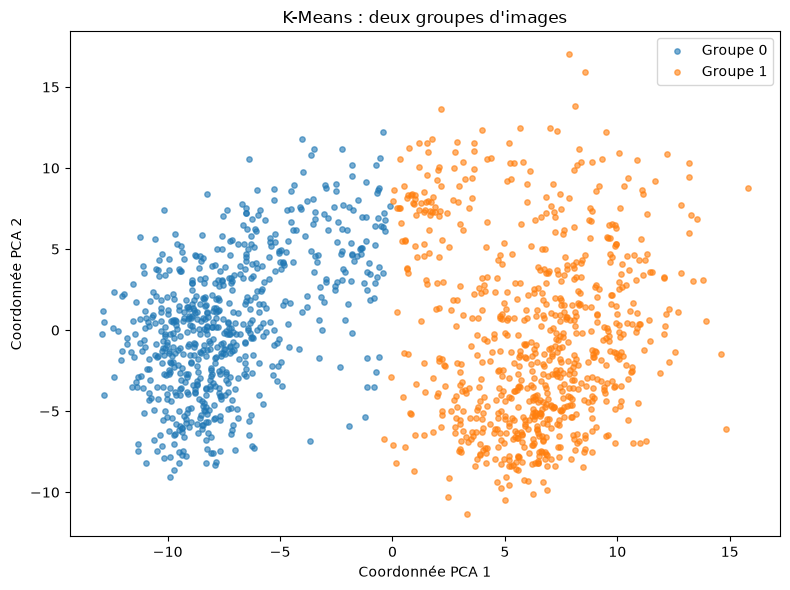

In [97]:
plt.figure(figsize=(8, 6))

for groupe in [0, 1]:
    selection = groupes_kmeans == groupe
    plt.scatter(X_pca[selection, 0], X_pca[selection, 1],
                s=15, alpha=0.6, label=f"Groupe {groupe}")

plt.xlabel("Coordonnée PCA 1")
plt.ylabel("Coordonnée PCA 2")
plt.title("K-Means : deux groupes d'images")
plt.legend()
plt.tight_layout()
plt.show()

K-Means répartit les images en deux groupes, principalement séparés par l'axe PCA (gauche vs droite). Les groupes présentent une dispersion interne. Cette représentation montre des différences entre les images, sans pour autant identifier chaque groupe comme étant: « normal » et « cancer ».

Réalisation du clustering avec K-Means

Choix de neuf combinaisaon à tester pour visualiser ensutie les resultats:
- eps (rayon du voisinage ): 0.5, 1.0, 2.0
- et repectivement min_samples (nombre minimum de points dans ce voisinage): 3, 5, 10.  ;

Chaque résultat est conservé dans essais_dbscan avec ses paramètres, ses numéros de groupes, le nombre de groupes et le nombre d'images hors groupe (-1).

In [98]:
essais_dbscan = []
dbscan = None
groupes_dbscan = None
nombre_groupes_dbscan = None
nombre_hors_groupe = None

for eps in [0.5, 1.0, 2.0]:
    for min_samples in [3, 5, 10]:
        dbscan_essai = DBSCAN(eps=eps, min_samples=min_samples)
        groupes_essai = dbscan_essai.fit_predict(X_pca)
        nombre_groupes_essai = len(set(groupes_essai) - {-1})
        nombre_hors_groupe_essai = int((groupes_essai == -1).sum())

        essais_dbscan.append({
            "eps": eps,
            "min_samples": min_samples,
            "groupes": groupes_essai,
            "nombre_groupes": nombre_groupes_essai,
            "nombre_hors_groupe": nombre_hors_groupe_essai,
        })

        print(f"eps={eps}, min_samples={min_samples} : "
              f"{nombre_groupes_essai} groupe(s), "
              f"{nombre_hors_groupe_essai} image(s) hors groupe")


eps=0.5, min_samples=3 : 72 groupe(s), 270 image(s) hors groupe
eps=0.5, min_samples=5 : 39 groupe(s), 516 image(s) hors groupe
eps=0.5, min_samples=10 : 16 groupe(s), 1106 image(s) hors groupe
eps=1.0, min_samples=3 : 8 groupe(s), 41 image(s) hors groupe
eps=1.0, min_samples=5 : 7 groupe(s), 78 image(s) hors groupe
eps=1.0, min_samples=10 : 7 groupe(s), 234 image(s) hors groupe
eps=2.0, min_samples=3 : 1 groupe(s), 5 image(s) hors groupe
eps=2.0, min_samples=5 : 1 groupe(s), 6 image(s) hors groupe
eps=2.0, min_samples=10 : 1 groupe(s), 10 image(s) hors groupe


Affichage d'un graphique pour chaque essai de paramètre avec DBSCAN: Une couleur représente chaque groupe ; les points hors groupe (`-1`) sont affichés en gris.



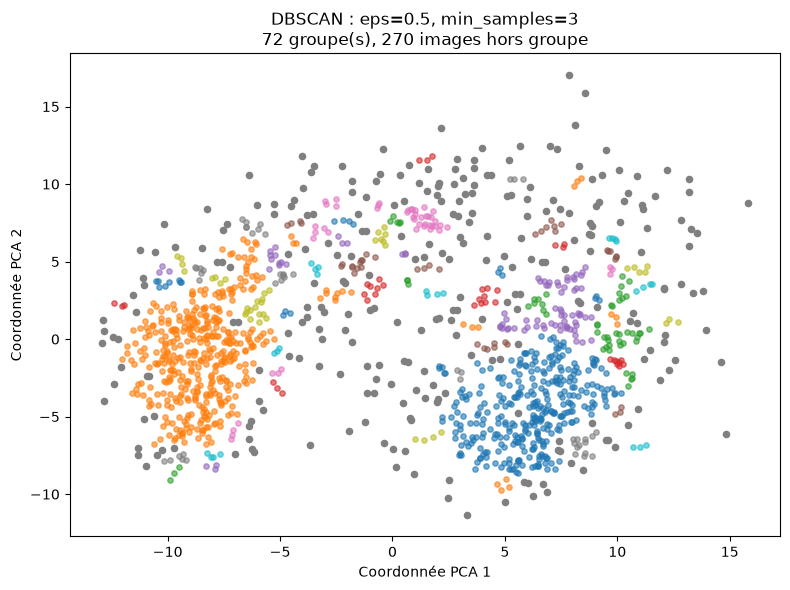

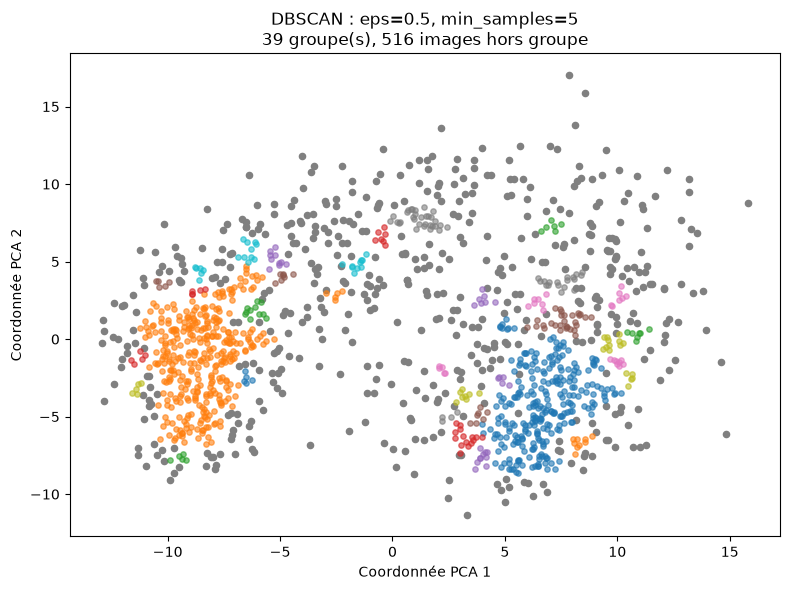

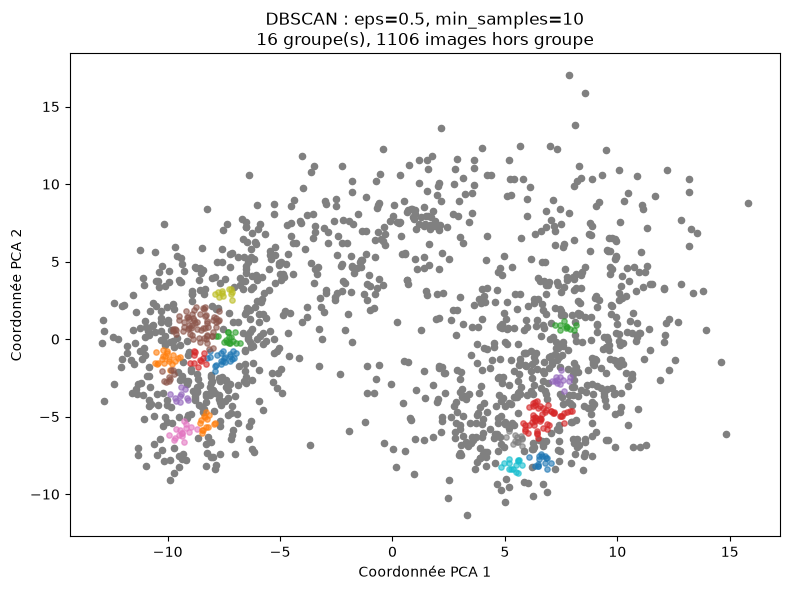

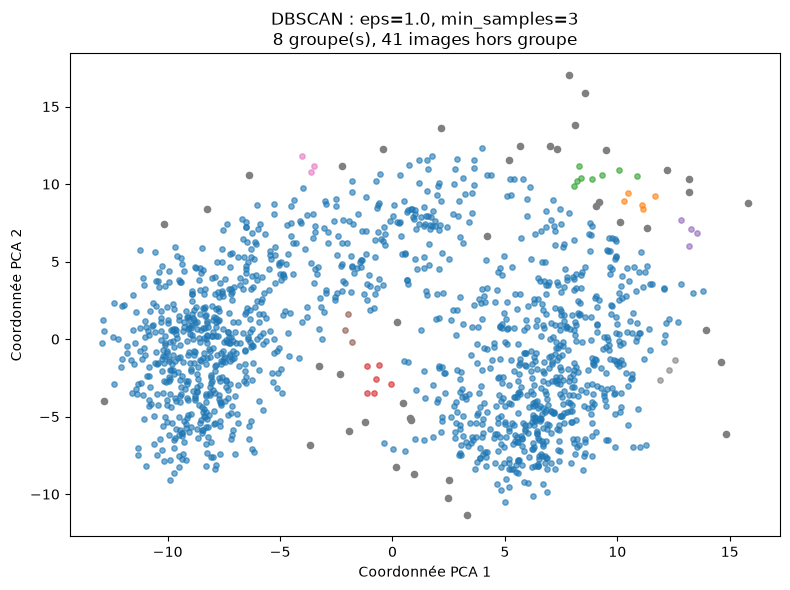

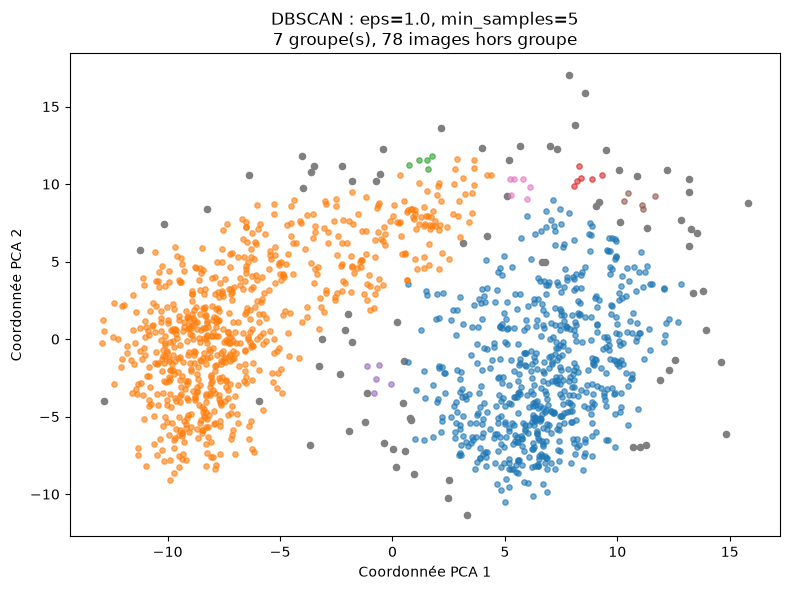

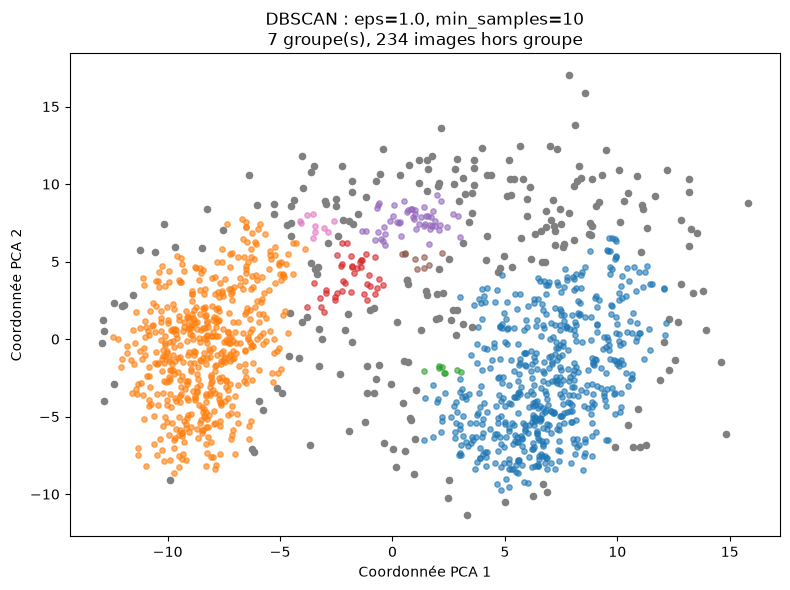

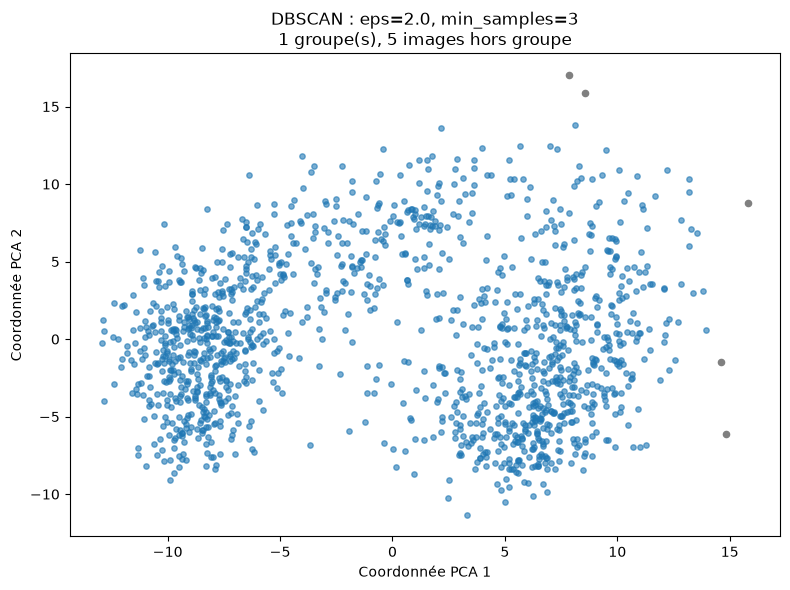

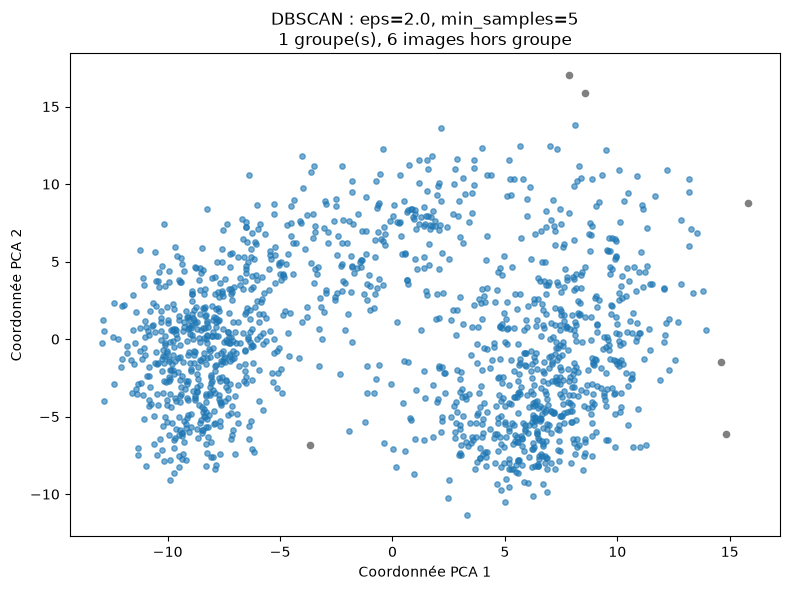

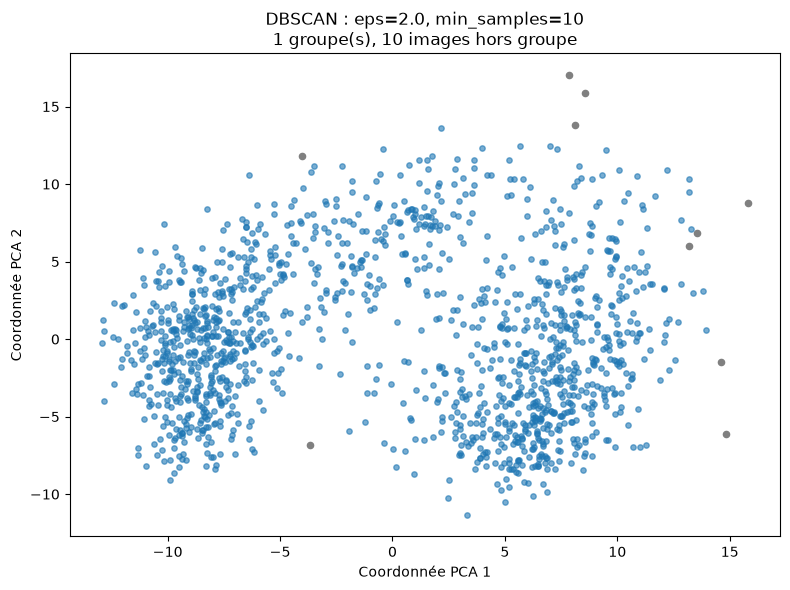

In [99]:
for essai in essais_dbscan:
    groupes_essai = essai["groupes"]
    plt.figure(figsize=(8, 6))

    for groupe in sorted(set(groupes_essai)):
        selection = groupes_essai == groupe
        if groupe == -1:
            plt.scatter(X_pca[selection, 0], X_pca[selection, 1],
                        s=20, color="gray", label="Hors groupe (-1)")
        else:
            plt.scatter(X_pca[selection, 0], X_pca[selection, 1],
                        s=15, alpha=0.6, label=f"Groupe {groupe}")

    plt.xlabel("Coordonnée PCA 1")
    plt.ylabel("Coordonnée PCA 2")
    plt.title(
        f"DBSCAN : eps={essai['eps']}, min_samples={essai['min_samples']}\n"
        f"{essai['nombre_groupes']} groupe(s), "
        f"{essai['nombre_hors_groupe']} images hors groupe"
    )
    plt.tight_layout()
    plt.show()

DBSCAN apporte une comparaison exploratoire et montre la sensibilité du regroupement à la densité. Son utilité pour distinguer les deux catégories médicales "cancer" et "normale" n'est par contre pas démontré

Comparaison de K-Means et les neuf essais DBSCAN avec l'ARI

Comparaison avec le groupe aux labels des 100 images étiquetées'utilisation de donnees_fortes et de masque_fort. Les images sans label ne participent pas au calcul du score.

L'**ARI** mesure l'accord entre deux regroupements


In [100]:
labels_reference = donnees_fortes["label_fort"]
selection_forte = masque_fort.to_numpy()

ari_kmeans = adjusted_rand_score(
    labels_reference,
    groupes_kmeans[selection_forte]
)

resultats_ari = [{
    "Méthode": "K-Means",
    "eps": None,
    "min_samples": None,
    "Nombre de groupes": len(set(groupes_kmeans)),
    "Images hors groupe": 0,
    "ARI sur les labels connus": ari_kmeans,
}]

for essai in essais_dbscan:
    ari_essai = adjusted_rand_score(
        labels_reference,
        essai["groupes"][selection_forte]
    )

    resultats_ari.append({
        "Méthode": "DBSCAN",
        "eps": essai["eps"],
        "min_samples": essai["min_samples"],
        "Nombre de groupes": essai["nombre_groupes"],
        "Images hors groupe": essai["nombre_hors_groupe"],
        "ARI sur les labels connus": ari_essai,
    })

scores_ari = pd.DataFrame(resultats_ari)
display(scores_ari)

,Méthode,eps,min_samples,Nombre de groupes,Images hors groupe,ARI sur les labels connus
0,K-Means,NaN,NaN,2,0,0.349172
1,DBSCAN,0.5,3.0,72,270,0.186301
2,DBSCAN,0.5,5.0,39,516,0.097766
3,DBSCAN,0.5,10.0,16,1106,0.024160
4,DBSCAN,1.0,3.0,8,41,-0.000404
5,DBSCAN,1.0,5.0,7,78,0.302170
6,DBSCAN,1.0,10.0,7,234,0.317908
7,DBSCAN,2.0,3.0,1,5,0.000000
8,DBSCAN,2.0,5.0,1,6,0.000000
9,DBSCAN,2.0,10.0,1,10,0.000000


KMEANS représente le meilleur score ARI donc nous utilison sle classement de cette méthode

Le code copie donnees_sans_label dans donnees_faibles, puis ajoute la colonne label_faible. Les valeurs 0 et 1 sont les numéros des groupes K-Means ; elles ne signifient pas automatiquement « normal » et « cancer ».
Les données fortement labellisées restent dans un tableau séparé.

In [101]:
donnees_faibles = donnees_sans_label.copy()
donnees_faibles["label_faible"] = groupes_kmeans[masque_sans_label.to_numpy()]

print("Méthode utilisée pour les labels faibles : K-Means")
print("Images fortement labellisées, conservées séparément :", len(donnees_fortes))
print("Images faiblement labellisées :", len(donnees_faibles))
display(donnees_faibles[["chemin", "label_faible"]].head())
display(donnees_faibles["label_faible"].value_counts().sort_index().to_frame("Nombre d'images"))

Méthode utilisée pour les labels faibles : K-Means
Images fortement labellisées, conservées séparément : 99
Images faiblement labellisées : 1311


,chemin,label_faible
99,sans_label/001b158a-7af8-451e-bf31-3a9116265f3...,1
100,sans_label/00366e8d-5520-4d3c-a70b-91a7eec1f52...,0
101,sans_label/00455a62-f79f-4072-9a23-4951e759acd...,0
102,sans_label/004ce5f5-ca6b-490f-9b2f-c322c152e2e...,0
103,sans_label/005d9a37-8894-4eb5-8367-1015d4a4363...,1


,Nombre d'images
label_faible,
0,590
1,721


### Étape 4 — Entraînement du CNN



Séparation des données de test et de train

In [ ]:


fortes_train, fortes_test = train_test_split(
    donnees_fortes,
    test_size=0.2,
    stratify=donnees_fortes["label_fort"],
    random_state=42,
)

fortes_train = fortes_train.copy()
fortes_test = fortes_test.copy()
faibles_train = donnees_faibles.copy()

effectifs_etape4 = pd.DataFrame({
    "Entraînement fort": fortes_train["label_fort"].value_counts(),
    "Test": fortes_test["label_fort"].value_counts(),
}).reindex(["normal", "cancer"]).fillna(0).astype(int)

display(effectifs_etape4)
print("Images pour l'entraînement faible :", len(faibles_train))

,Entraînement fort,Test
label_fort,,
normal,39,10
cancer,40,10


Images pour l'entraînement faible : 1311


### 4.2. Donner une signification commune aux labels des deux entraînements

Les labels faibles `0/1` désignent des groupes K-Means. Cette cellule compare ces groupes aux labels des images de `fortes_train`, puis associe chaque groupe à sa classe majoritaire. Les labels du test n'interviennent pas dans cette correspondance.

Les cibles du CNN sont codées **0 = normal** et **1 = cancer**. Ce codage est appliqué aux ensembles forts et aux labels faibles estimés. La correspondance des groupes reste approximative.

**Résultat attendu :** la répartition des classes d'entraînement dans les groupes K-Means, la correspondance retenue et les effectifs des cibles faibles.

In [103]:
groupes_forts_train = pd.Series(
    groupes_kmeans, index=features.index, name="Groupe K-Means"
).loc[fortes_train.index]

repartition_train = pd.crosstab(
    groupes_forts_train,
    fortes_train["label_fort"],
    colnames=["Label d'entraînement"],
)
correspondance_groupes = repartition_train.idxmax(axis=1).to_dict()
encodage_classes = {"normal": 0, "cancer": 1}

fortes_train["cible"] = fortes_train["label_fort"].map(encodage_classes)
fortes_test["cible"] = fortes_test["label_fort"].map(encodage_classes)
faibles_train["label_estime"] = faibles_train["label_faible"].map(correspondance_groupes)
faibles_train["cible"] = faibles_train["label_estime"].map(encodage_classes)

display(repartition_train)
print("Correspondance groupe / classe :", correspondance_groupes)
display(faibles_train["label_estime"].value_counts().to_frame("Images faibles"))

Label d'entraînement,cancer,normal
Groupe K-Means,,
0,14,37
1,26,2


Correspondance groupe / classe : {0: 'normal', 1: 'cancer'}


,Images faibles
label_estime,
cancer,721
normal,590


### 4.3. Préparer les lots d'images et les réglages d'entraînement

Cette cellule retrouve dans `images_preparees` les images de chaque tableau grâce à leur chemin. Elles ont déjà reçu le prétraitement de ResNet18 à l'étape 2. Le CNN recevra les **images**, avec leurs cibles entières, et non les coordonnées PCA.

`TensorDataset` associe chaque image à sa cible ; `DataLoader` les regroupe par lots de 16. Les lots d'entraînement sont mélangés avec une graine fixe ; le test n'est pas mélangé.

Les réglages de ce premier essai sont fixés avant l'évaluation : **5 époques sur les labels faibles, 5 époques sur les labels forts et un taux d'apprentissage de 0.001**. Une époque correspond à un passage sur toutes les images de l'ensemble d'entraînement.

**Résultat attendu :** le nombre de lots, la forme d'un lot et l'appareil utilisé. Aucun entraînement n'est encore effectué.

In [104]:
from torch.utils.data import TensorDataset, DataLoader

taille_lot_etape4 = 16
epoques_faibles = 5
epoques_fortes = 5
taux_apprentissage = 0.001
appareil_etape4 = torch.device("cuda" if torch.cuda.is_available() else "cpu")

positions_images = {
    chemin.relative_to(dossier_dataset).as_posix(): position
    for position, chemin in enumerate(chemins_images)
}

def creer_chargeur(tableau, melanger):
    images = torch.stack([
        images_preparees[positions_images[chemin]]
        for chemin in tableau["chemin"]
    ])
    cibles = torch.tensor(tableau["cible"].to_numpy(), dtype=torch.long)
    dataset = TensorDataset(images, cibles)
    return DataLoader(
        dataset,
        batch_size=taille_lot_etape4,
        shuffle=melanger,
        generator=torch.Generator().manual_seed(42),
    )

chargeur_faible = creer_chargeur(faibles_train, melanger=True)
chargeur_fort = creer_chargeur(fortes_train, melanger=True)
chargeur_test = creer_chargeur(fortes_test, melanger=False)

print("Lots faibles :", len(chargeur_faible))
print("Lots forts :", len(chargeur_fort))
print("Lots de test :", len(chargeur_test))
print("Forme d'un lot d'images :", tuple(chargeur_test.dataset.tensors[0][:16].shape))
print("Appareil utilisé :", appareil_etape4)

Lots faibles : 82
Lots forts : 5
Lots de test : 2
Forme d'un lot d'images : (16, 3, 224, 224)
Appareil utilisé : cpu


### 4.4. Créer deux CNN avec les mêmes poids initiaux

Cette cellule crée deux **nouveaux ResNet18** avec les poids `poids` déjà choisis. Elle gèle leurs paramètres, puis remplace la couche finale par une couche entraînable à deux sorties : `normal` et `cancer`. Seule cette dernière couche sera entraînée, pour garder une approche simple.

La graine est réinitialisée avant chaque création : les modèles `modele_semi` et `modele_supervise` commencent avec les mêmes poids. Le modèle d'extraction de l'étape 2 n'est pas modifié.

`CrossEntropyLoss` est la fonction de perte. Chaque modèle possède son optimiseur Adam, appliqué uniquement à sa couche finale.

**Résultat attendu :** le nombre de paramètres entraînables de chaque CNN.

In [105]:
def creer_cnn():
    torch.manual_seed(42)
    cnn = models.resnet18(weights=poids)
    for parametre in cnn.parameters():
        parametre.requires_grad = False
    cnn.fc = torch.nn.Linear(cnn.fc.in_features, 2)
    return cnn.to(appareil_etape4)

modele_semi = creer_cnn()
modele_supervise = creer_cnn()
fonction_perte = torch.nn.CrossEntropyLoss()

optimiseur_semi = torch.optim.Adam(
    modele_semi.fc.parameters(), lr=taux_apprentissage
)
optimiseur_supervise = torch.optim.Adam(
    modele_supervise.fc.parameters(), lr=taux_apprentissage
)

for nom, cnn in [("Semi-supervisé", modele_semi), ("Supervisé", modele_supervise)]:
    print(nom, ": paramètres entraînables =", sum(
        parametre.numel() for parametre in cnn.parameters()
        if parametre.requires_grad
    ))

Semi-supervisé : paramètres entraînables = 1026
Supervisé : paramètres entraînables = 1026


### 4.5. Définir l'entraînement et l'évaluation

Cette cellule définit deux fonctions, sans les appliquer encore.

`entrainer_cnn` parcourt les lots, calcule la perte, puis ajuste les poids de la couche finale. Le reste de ResNet18 reste en mode évaluation pour conserver ses statistiques internes. La fonction affichera la perte moyenne de chaque époque.

`evaluer_cnn` prédit les classes du test sans modifier les poids. Elle construit une matrice de confusion : lignes = classes connues ; colonnes = classes prédites, dans l'ordre `normal, cancer`.

Elle calcule **l'accuracy**, le **F1-score de cancer** et le **rappel de cancer**. L'accuracy mesure la proportion de prédictions correctes ; le F1 combine précision et rappel ; le rappel indique la proportion des images `cancer` retrouvées. Ce dernier permet d'observer les faux négatifs, sans fixer de seuil de performance ni d'arbitrage clinique.

**Résultat attendu :** un message confirmant que les fonctions sont définies.

In [106]:
def entrainer_cnn(cnn, chargeur, optimiseur, nombre_epoques):
    chargeur.generator.manual_seed(42)
    pertes = []

    for epoque in range(nombre_epoques):
        cnn.eval()
        cnn.fc.train()
        perte_totale = 0.0

        for images_lot, cibles_lot in chargeur:
            images_lot = images_lot.to(appareil_etape4)
            cibles_lot = cibles_lot.to(appareil_etape4)

            optimiseur.zero_grad()
            sorties = cnn(images_lot)
            perte = fonction_perte(sorties, cibles_lot)
            perte.backward()
            optimiseur.step()
            perte_totale += perte.item() * len(cibles_lot)

        perte_moyenne = perte_totale / len(chargeur.dataset)
        pertes.append(perte_moyenne)
        print(f"Époque {epoque + 1}/{nombre_epoques} : perte = {perte_moyenne:.4f}")

    return pertes

def evaluer_cnn(cnn, chargeur):
    cnn.eval()
    matrice = np.zeros((2, 2), dtype=int)

    with torch.no_grad():
        for images_lot, cibles_lot in chargeur:
            sorties = cnn(images_lot.to(appareil_etape4))
            predictions = sorties.argmax(dim=1).cpu()
            for vraie_classe, classe_predite in zip(
                cibles_lot.tolist(), predictions.tolist()
            ):
                matrice[vraie_classe, classe_predite] += 1

    vrais_negatifs, faux_positifs, faux_negatifs, vrais_positifs = matrice.ravel()
    mesures = {
        "Accuracy": (vrais_negatifs + vrais_positifs) / matrice.sum(),
        "F1 cancer": 2 * vrais_positifs / (
            2 * vrais_positifs + faux_positifs + faux_negatifs
        ),
        "Rappel cancer": vrais_positifs / (vrais_positifs + faux_negatifs),
    }
    return mesures, matrice

print("Fonctions d'entraînement et d'évaluation définies.")

Fonctions d'entraînement et d'évaluation définies.


### 4.6. Entraîner le premier CNN sur les labels faibles

Cette cellule entraîne `modele_semi` sur `chargeur_faible` pendant `epoques_faibles` époques. Les cibles utilisées sont les labels faibles estimés à partir des groupes K-Means.

Elle évalue ensuite ce CNN sur `chargeur_test`, avec les **labels forts d'origine**. Les images de test et leurs copies ont été écartées de l'entraînement.

**Résultat attendu :** les pertes par époque, puis les trois métriques du CNN après l'entraînement faible. Ces métriques ne servent pas à régler le modèle.

In [107]:
pertes_faibles = entrainer_cnn(
    modele_semi, chargeur_faible, optimiseur_semi, epoques_faibles
)
mesures_faibles, confusion_faibles = evaluer_cnn(modele_semi, chargeur_test)

display(pd.DataFrame(
    [mesures_faibles], index=["Après entraînement faible"]
).round(3))

Époque 1/5 : perte = 0.2425
Époque 2/5 : perte = 0.0787
Époque 3/5 : perte = 0.0594
Époque 4/5 : perte = 0.0495
Époque 5/5 : perte = 0.0427


,Accuracy,F1 cancer,Rappel cancer
Après entraînement faible,0.8,0.75,0.6


### 4.7. Poursuivre le même CNN sur les labels forts

Cette cellule poursuit l'entraînement de **`modele_semi` sans réinitialiser ses poids**, avec `chargeur_fort`, les labels d'origine et `epoques_fortes` époques. Elle conserve aussi son optimiseur.

Le CNN est ensuite évalué sur le même test qu'en 4.6. Il a maintenant été entraîné successivement sur les données faibles puis sur les données fortes, tout en gardant ces ensembles séparés.

**Résultat attendu :** les pertes par époque et les métriques du modèle semi-supervisé.

In [108]:
pertes_semi = entrainer_cnn(
    modele_semi, chargeur_fort, optimiseur_semi, epoques_fortes
)
mesures_semi, confusion_semi = evaluer_cnn(modele_semi, chargeur_test)

display(pd.DataFrame(
    [mesures_semi], index=["Semi-supervisé : faible puis fort"]
).round(3))

Époque 1/5 : perte = 0.9268
Époque 2/5 : perte = 0.6230
Époque 3/5 : perte = 0.6078
Époque 4/5 : perte = 0.5270
Époque 5/5 : perte = 0.4697


,Accuracy,F1 cancer,Rappel cancer
Semi-supervisé : faible puis fort,0.9,0.889,0.8


### 4.8. Entraîner le CNN supervisé sur les labels forts uniquement

Cette cellule entraîne `modele_supervise`, resté à ses poids initiaux, uniquement sur `chargeur_fort`. Elle utilise les mêmes images fortes d'entraînement, le même nombre d'époques fortes, le même taux d'apprentissage et le même ordre des lots que la phase forte du modèle semi-supervisé.

Elle évalue ensuite ce CNN sur le même `chargeur_test`. Les deux modèles diffèrent par la présence ou l'absence d'une phase d'entraînement sur les données faibles.

**Résultat attendu :** les pertes par époque et les métriques du modèle supervisé.

In [109]:
pertes_supervise = entrainer_cnn(
    modele_supervise, chargeur_fort, optimiseur_supervise, epoques_fortes
)
mesures_supervise, confusion_supervise = evaluer_cnn(
    modele_supervise, chargeur_test
)

display(pd.DataFrame(
    [mesures_supervise], index=["Supervisé : fort uniquement"]
).round(3))

Époque 1/5 : perte = 0.6678
Époque 2/5 : perte = 0.5192
Époque 3/5 : perte = 0.4195
Époque 4/5 : perte = 0.3781
Époque 5/5 : perte = 0.3143


,Accuracy,F1 cancer,Rappel cancer
Supervisé : fort uniquement,0.95,0.947,0.9


### 4.9. Comparer les performances et lire les erreurs

Cette cellule réunit les trois évaluations dans un tableau et affiche leurs matrices de confusion avec la même échelle de couleurs. Les lignes correspondent aux labels connus du test et les colonnes aux prédictions.

La case `cancer → normal` contient les faux négatifs ; la case `normal → cancer` contient les faux positifs. Le code affiche aussi la différence de F1 entre le modèle semi-supervisé et le modèle supervisé.

**Résultat attendu :** le tableau comparatif, trois matrices de confusion et un commentaire sur le gain, l'égalité ou la baisse du F1 après entraînement semi-supervisé. L'étape répond ainsi à la comparaison demandée, même si le semi-supervisé n'améliore pas les résultats.

Ces résultats restent exploratoires : le test est petit, aucun seuil de réussite clinique n'est défini, et le clustering ainsi que son choix par ARI ont déjà utilisé l'ensemble des données aux étapes précédentes. Cette évaluation ne constitue donc pas une validation indépendante de toute la chaîne.

,Accuracy,F1 cancer,Rappel cancer
Faible uniquement,0.80,0.750,0.6
Semi-supervisé : faible puis fort,0.90,0.889,0.8
Supervisé : fort uniquement,0.95,0.947,0.9


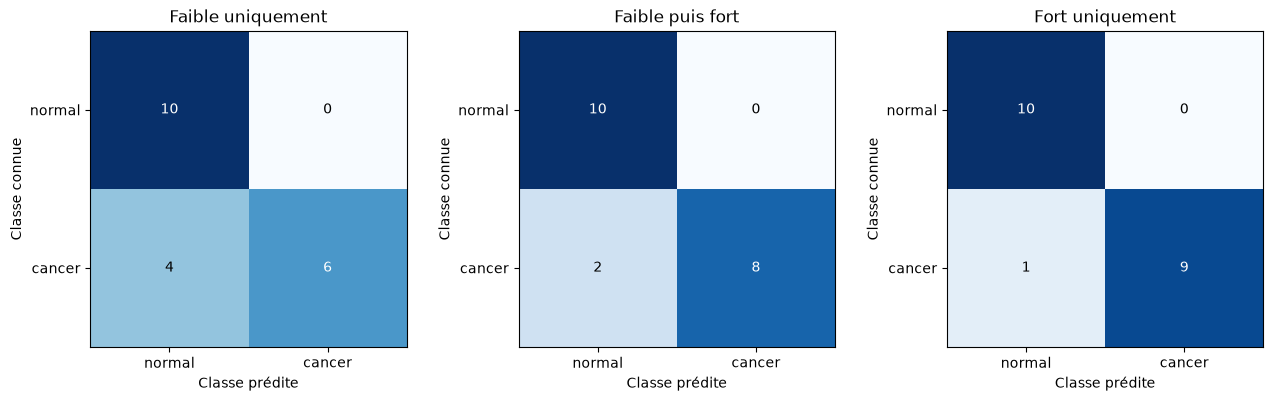

Écart de F1 (semi-supervisé - supervisé) : -0.058
Sur ce test, le modèle supervisé obtient un F1 cancer supérieur.


In [110]:
comparaison_etape4 = pd.DataFrame(
    [mesures_faibles, mesures_semi, mesures_supervise],
    index=[
        "Faible uniquement",
        "Semi-supervisé : faible puis fort",
        "Supervisé : fort uniquement",
    ],
)
display(comparaison_etape4.round(3))

matrices_etape4 = [confusion_faibles, confusion_semi, confusion_supervise]
titres_etape4 = ["Faible uniquement", "Faible puis fort", "Fort uniquement"]
maximum_effectifs = max(matrice.max() for matrice in matrices_etape4)
figure, axes = plt.subplots(1, 3, figsize=(13, 4))

for axe, matrice, titre in zip(axes, matrices_etape4, titres_etape4):
    axe.imshow(matrice, cmap="Blues", vmin=0, vmax=maximum_effectifs)
    axe.set_xticks([0, 1], ["normal", "cancer"])
    axe.set_yticks([0, 1], ["normal", "cancer"])
    axe.set_xlabel("Classe prédite")
    axe.set_ylabel("Classe connue")
    axe.set_title(titre)

    for ligne in range(2):
        for colonne in range(2):
            couleur = "white" if matrice[ligne, colonne] > maximum_effectifs / 2 else "black"
            axe.text(
                colonne, ligne, str(matrice[ligne, colonne]),
                ha="center", va="center", color=couleur
            )

plt.tight_layout()
plt.show()

ecart_f1 = mesures_semi["F1 cancer"] - mesures_supervise["F1 cancer"]
print(f"Écart de F1 (semi-supervisé - supervisé) : {ecart_f1:+.3f}")

if ecart_f1 > 0:
    print("Sur ce test, le modèle semi-supervisé obtient un F1 cancer supérieur.")
elif ecart_f1 < 0:
    print("Sur ce test, le modèle supervisé obtient un F1 cancer supérieur.")
else:
    print("Sur ce test, les deux modèles obtiennent le même F1 cancer.")